# Initializatoin

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
cd /content/drive/MyDrive/Colab\ Notebooks/DL/HW3

/content/drive/MyDrive/Colab Notebooks/DL/HW3


## Imports

In [ ]:
import math
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.datasets as datasets
import torchvision.transforms as transforms

from torch.autograd import Variable
from torch.nn import Parameter

from name_dataset import Dataset

# RNN

## Traditional RNN

In the introductory section, we delve into the architecture of Recurrent Neural Networks (RNNs) and elucidate their training methodologies. To gain a deeper understanding of RNNs, you're encouraged to explore further [HERE](https://stanford.edu/~shervine/teaching/cs-230/cheatsheet-recurrent-neural-network)

For the task at hand, you've been furnished with the Names dataset, a compilation comprising thousands of surnames from 18 distinct languages of origin. Your objective is to prognosticate the language of origin for a given name, relying solely on its orthography. Your task primarily involves implementing the section demarcated by `#your_code`.

In [ ]:
dataset = Dataset()
for i in range(10):
    category, line, _, _ = dataset.randomTrainingExample()
    print('category =', category, '- random name =', line)

Error occurred while downloading data.zip: --2024-04-26 20:28:38--  https://download.pytorch.org/tutorial/data.zip
Resolving download.pytorch.org (download.pytorch.org)... 13.225.4.72, 13.225.4.109, 13.225.4.31, ...
Connecting to download.pytorch.org (download.pytorch.org)|13.225.4.72|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2882130 (2.7M) [application/zip]
Saving to: ‘data.zip’

     0K .......... .......... .......... .......... ..........  1% 12.2M 0s
    50K .......... .......... .......... .......... ..........  3% 33.2M 0s
   100K .......... .......... .......... .......... ..........  5% 43.5M 0s
   150K .......... .......... .......... .......... ..........  7% 66.1M 0s
   200K .......... .......... .......... .......... ..........  8% 55.1M 0s
   250K .......... .......... .......... .......... .......... 10% 40.3M 0s
   300K .......... .......... .......... .......... .......... 12% 42.0M 0s
   350K .......... .......... .......... .......... 

In [ ]:
class RNN(nn.Module):
  def __init__(self, input_size, hidden_size, output_size):
    super(RNN, self).__init__()
    #your_code
    self.hidden_size = hidden_size
    self.i2h = nn.Linear(input_size + hidden_size, hidden_size)
    self.h2o = nn.Linear(hidden_size, output_size)
    self.softmax = nn.LogSoftmax(dim=1)

  def forward(self, input, hidden):

    #your_code
    combined = torch.cat((input, hidden), 1)
    hidden = self.i2h(combined)
    hidden = torch.tanh(hidden)
    output = self.h2o(hidden)
    output = self.softmax(output)
    return output, hidden

  def initHidden(self):
    # initialization the weights randomly in the interval from[ -1/sqrt(n), 1/sqrt(n)]where n is the number of incoming connections from the previous layer
    r1 = torch.sqrt(torch.tensor(1./self.hidden_size))
    return (-r1 - r1)*torch.rand(1, self.hidden_size)

n_hidden = 128
n_letters = dataset.n_letters
n_categories = dataset.n_categories
rnn = RNN(n_letters, n_hidden, n_categories)

In [ ]:
#your_code
criterion = nn.NLLLoss()
learning_rate = 0.005

def train(category_tensor, name_tensor):
    hidden = rnn.initHidden()
    rnn.zero_grad()

    #your_code
    for i in range(name_tensor.size()[0]):
        output, hidden = rnn(name_tensor[i], hidden)

    loss = criterion(output, category_tensor)
    loss.backward()

    # Add parameters' gradients to their values, multiplied by learning rate
    for p in rnn.parameters():
        p.data.add_(p.grad.data, alpha=-learning_rate)

    return output, loss.item()

And here you can train your model and see it's performance after each 5000 iterations

In [ ]:
n_iters = 100000
print_every = 5000

current_loss = 0
all_losses = []

for iter in range(1, n_iters + 1):
    category, line, category_tensor, line_tensor = dataset.randomTrainingExample()
    output, loss = train(category_tensor, line_tensor)
    current_loss += loss

    if iter % print_every == 0:
        guess, _ = dataset.categoryFromOutput(output)
        correct = '✓' if guess == category else '✗ (%s)' % category
        print('%d %d%% %.4f %s is predicted as a "%s" name, status = %s' % (iter, iter / n_iters * 100, loss, line, guess, correct))

    if iter % 1000 == 0:
        all_losses.append(current_loss / 1000)
        current_loss = 0


5000 5% 2.7023 Connolly is predicted as a "Russian" name, status = ✗ (Irish)
10000 10% 3.4628 Thomas is predicted as a "Arabic" name, status = ✗ (French)
15000 15% 1.9206 Netsch is predicted as a "Czech" name, status = ✓
20000 20% 2.1827 Depp is predicted as a "Dutch" name, status = ✗ (English)
25000 25% 0.9547 Huber is predicted as a "German" name, status = ✓
30000 30% 2.2310 Wiater is predicted as a "Arabic" name, status = ✗ (Polish)
35000 35% 0.3593 Morrison is predicted as a "Scottish" name, status = ✓
40000 40% 0.5975 Dasios is predicted as a "Greek" name, status = ✓
45000 45% 1.8522 Paget is predicted as a "French" name, status = ✓
50000 50% 0.4768 Marion is predicted as a "French" name, status = ✓
55000 55% 2.1006 Grant is predicted as a "German" name, status = ✗ (Scottish)
60000 60% 0.7389 Garver is predicted as a "German" name, status = ✓
65000 65% 1.4350 Sommer is predicted as a "Dutch" name, status = ✗ (German)
70000 70% 0.5819 Urbina is predicted as a "Spanish" name, status

Text(0.5, 1.0, 'total loss in every 1000 iteration')

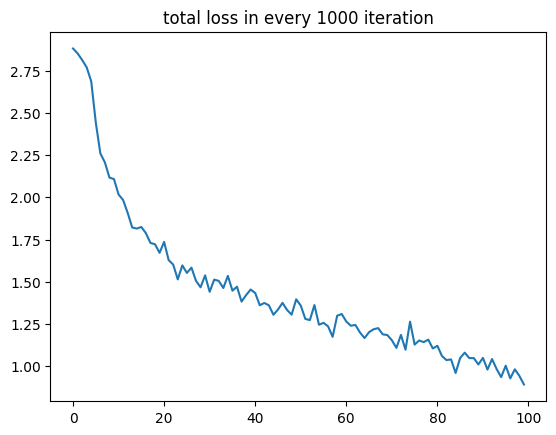

In [ ]:
plt.figure()
plt.plot(all_losses)
plt.title("total loss in every 1000 iteration")

## Traditional RNN Disadvantages

In this part, we aim to delve into the limitations of traditional RNNs:
1.   Recurrent computation is slow
2.   They have difficulty accessing information from many steps back.

You are provided with a simple code that helps you to give the idea better. By modifying this code, you are able to demonstrate the mentioned disadvantages, but you are also free to change the code if needed or use any dataset you want.

**Question:** Do you think using GPU instead of CPU completely solves the first problem?

Note: The main goal of this part is to help you understand these problems better. Don't be too hard to implement and delivery.

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Generate sinusoidal temperature data with decreasing range over time
np.random.seed(0)
num_periods = 50
timesteps_per_period = 10
total_timesteps = num_periods * timesteps_per_period

decreasing_factor = np.linspace(1, 0.1, total_timesteps)
temperature_data = np.sin(np.linspace(0, 2*np.pi*num_periods, total_timesteps)) * decreasing_factor
temperature_data = (temperature_data - np.mean(temperature_data)) / np.std(temperature_data)
temperature_data = torch.tensor(temperature_data, dtype=torch.float32).view(-1, 1)

def create_dataset(data, seq_length):
    X, Y = [], []
    for i in range(len(data) - seq_length):
        seq_in = data[i:i+seq_length]
        seq_out = data[i+seq_length]
        X.append(seq_in)
        Y.append(seq_out)
    return torch.stack(X), torch.stack(Y)

sequence_length = 25  # Number of prev days to look at for prediction
X, Y = create_dataset(temperature_data, sequence_length)

train_size = int(0.8 * len(X))
test_size = len(X) - train_size
X_train, X_test = X[:train_size], X[train_size:]
Y_train, Y_test = Y[:train_size], Y[train_size:]

In [ ]:

class SimpleRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(SimpleRNN, self).__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.fc(out[:, -1, :])
        return out


input_size = 1
hidden_size = 10
output_size = 1

model = SimpleRNN(input_size, hidden_size, output_size)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


In [ ]:
num_epochs = 100
for epoch in range(num_epochs):
    model.train()
    outputs = model(X_train)
    loss = criterion(outputs, Y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')


Epoch [10/100], Loss: 0.8696
Epoch [20/100], Loss: 0.8096
Epoch [30/100], Loss: 0.7499
Epoch [40/100], Loss: 0.6892
Epoch [50/100], Loss: 0.6268
Epoch [60/100], Loss: 0.5616
Epoch [70/100], Loss: 0.4926
Epoch [80/100], Loss: 0.4192
Epoch [90/100], Loss: 0.3419
Epoch [100/100], Loss: 0.2640


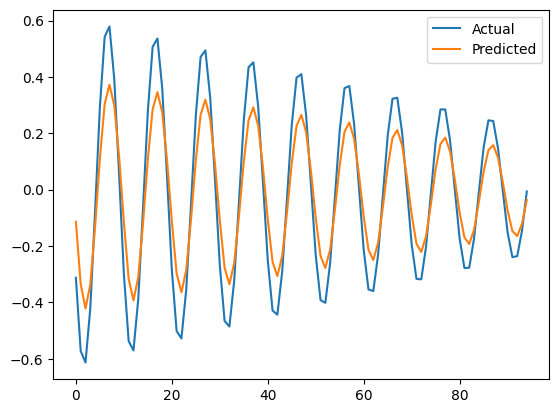

In [ ]:

model.eval()
with torch.no_grad():
    test_predictions = model(X_test)

# Plot actual vs predicted
plt.plot(Y_test.numpy(), label='Actual')
plt.plot(test_predictions.numpy(), label='Predicted')
plt.legend()
plt.show()

# LSTM Preparation

Now that you have experience with traditional RNNs, it's time to implement the LSTM model. Your goal is to implement the cell and model for LSTM architecture. The proposed dataset for this section is MNIST, allowing you to focus solely on model implementation.

In [ ]:
is_cuda = torch.cuda.is_available()
device = torch.device("cuda") if is_cuda else torch.device("cpu")

In [ ]:
train_dataset = datasets.MNIST(root='./data',
                               train=True,
                               transform=transforms.ToTensor(),
                               download=True)

test_dataset = datasets.MNIST(root='./data',
                              train=False,
                              transform=transforms.ToTensor())

batch_size = 128
n_iters = 6000
num_epochs = int(n_iters / (len(train_dataset) / batch_size))

Failed to download (trying next):
HTTP Error 503: Service Unavailable



100%|██████████| 9912422/9912422 [00:02<00:00, 4614921.88it/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 503: Service Unavailable



100%|██████████| 28881/28881 [00:00<00:00, 134728.60it/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw



100%|██████████| 1648877/1648877 [00:50<00:00, 32844.84it/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw



100%|██████████| 4542/4542 [00:00<00:00, 5562198.18it/s]

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



In [ ]:
train_loader = torch.utils.data.DataLoader(dataset=train_dataset,
                                           batch_size=batch_size,
                                           shuffle=True)

test_loader = torch.utils.data.DataLoader(dataset=test_dataset,
                                          batch_size=batch_size,
                                          shuffle=False)

## LSTM Cells

In [ ]:
class LSTMCell(nn.Module):
  def __init__(self, input_size, hidden_size, bias=True):
    super(LSTMCell, self).__init__()
    self.input_size = input_size
    self.hidden_size = hidden_size
    self.bias = bias

    self.xh = nn.Linear(input_size, hidden_size * 4, bias=bias).to(device)
    self.hh = nn.Linear(hidden_size, hidden_size * 4, bias=bias).to(device)
    self.reset_parameters()

  def reset_parameters(self):
    std = 1.0 / np.sqrt(self.hidden_size)
    for w in self.parameters():
        w.data.uniform_(-std, std)

  def forward(self, input, hx=None):
    # Inputs:
    #       input: of shape (batch_size, input_size)
    #       hx: of shape (batch_size, hidden_size)
    # Outputs:
    #       hy: of shape (batch_size, hidden_size)
    #       cy: of shape (batch_size, hidden_size)
    input = input.to(device)
    if hx is None:
        hx = Variable(input.new_zeros(input.size(0), self.hidden_size))
        hx = (hx, hx)
    hx, cx = hx
    gates = self.xh(input) + self.hh(hx)
    # Get gates (i_t, f_t, g_t, o_t)
    input_gate, forget_gate, cell_gate, output_gate = gates.chunk(4, 1)
    i_t = torch.sigmoid(input_gate)
    f_t = torch.sigmoid(forget_gate)
    g_t = torch.tanh(cell_gate)
    o_t = torch.sigmoid(output_gate)
    cy = cx * f_t + i_t * g_t
    hy = o_t * torch.tanh(cy.to(device))
    return (hy, cy)

## LSTM Models

In [ ]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, bias, output_size):
        super(LSTMModel, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.bias = bias
        self.output_size = output_size
        self.rnn_cell_list = nn.ModuleList()
        self.rnn_cell_list.append(LSTMCell(self.input_size,
                                            self.hidden_size,
                                            self.bias))
        for l in range(1, self.num_layers):
            self.rnn_cell_list.append(LSTMCell(self.hidden_size,
                                                self.hidden_size,
                                                self.bias))
        self.fc = nn.Linear(self.hidden_size, self.output_size)

    def forward(self, input, hx=None):
        # Input of shape (batch_size, seqence length , input_size)
        #
        # Output of shape (batch_size, output_size)
        if hx is None:
            h0 = Variable(torch.zeros(self.num_layers, input.size(0), self.hidden_size)).to(input.device)
        else:
             h0 = hx.to(input.device)
        outs = []
        hidden = list()
        for layer in range(self.num_layers):
            hidden.append((h0[layer, :, :].to(input.device), h0[layer, :, :].to(input.device)))
        for t in range(input.size(1)):
            for layer in range(self.num_layers):
                if layer == 0:
                    hidden_l = self.rnn_cell_list[layer](
                        input[:, t, :],
                        (hidden[layer][0],hidden[layer][1])
                        )
                else:
                    hidden_l = self.rnn_cell_list[layer](
                        hidden[layer - 1][0],
                        (hidden[layer][0], hidden[layer][1])
                        )
                hidden[layer] = hidden_l
            outs.append(hidden_l[0])
        out = outs[-1].squeeze()
        out = self.fc(out.to(self.fc.weight.device))
        return out.to(input.device)

In [ ]:
input_dim = 28
hidden_dim = 128
layer_dim = 1  # ONLY 1 OR 2
output_dim = 10
bias = True
model = LSTMModel(input_dim, hidden_dim, layer_dim, bias, output_dim)

# your code
learning_rate = 0.001
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [ ]:
# your code

# Train model and print Loss and Accuracy on Test Dataset after each 500 iterations
iter = 0
for epoch in range(num_epochs):
  for i, (images, labels) in enumerate(train_loader):
    images = Variable(images.view(-1, 28, 28).clone()).to(device)
    labels = Variable(labels).to(device)
    model.zero_grad()
    optimizer.zero_grad()
    outputs = model(images)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

    iter += 1
    if iter % 500 == 0:
      correct = 0
      total = 0
      for images, labels in test_loader:
        images = Variable(images.view(-1, 28, 28).clone()).to(device)
        labels = Variable(labels).to(device)
        outputs = model(images).to(device)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum()

      accuracy = 100 * correct / total
      print('Iteration: {}. Loss: {}. Accuracy: {}%'.format(iter, loss.item(), accuracy))


Iteration: 500. Loss: 0.22806884348392487. Accuracy: 93.47999572753906%
Iteration: 1000. Loss: 0.08866367489099503. Accuracy: 95.91999816894531%
Iteration: 1500. Loss: 0.08320678770542145. Accuracy: 96.79000091552734%
Iteration: 2000. Loss: 0.05469360575079918. Accuracy: 97.0999984741211%
Iteration: 2500. Loss: 0.03767184913158417. Accuracy: 97.68000030517578%
Iteration: 3000. Loss: 0.08323939144611359. Accuracy: 97.75999450683594%
Iteration: 3500. Loss: 0.07129927724599838. Accuracy: 97.79999542236328%
Iteration: 4000. Loss: 0.015847481787204742. Accuracy: 98.04999542236328%
Iteration: 4500. Loss: 0.054791856557130814. Accuracy: 98.25%
Iteration: 5000. Loss: 0.02245587855577469. Accuracy: 98.18999481201172%
Iteration: 5500. Loss: 0.014930453151464462. Accuracy: 98.37999725341797%


# Sentiment Analysis

Now you are ready to face a real-world problem. In this task, we want you to do a sentiment analysis on the [IMDB dataset](https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews). The main goal is to reach more than an acceptable accuracy of **75%** on LSTM model. You are free to use torch.nn.LSTM to design your architecture, but you must prepare the IMDB dataset on your own.

In [ ]:
!pip install datasets

In [2]:
import collections

import datasets
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torch.optim as optim
import torchtext
import tqdm

In [3]:
train_data, test_data = datasets.load_dataset("imdb", split=["train", "test"])

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [4]:
tokenizer_basic = torchtext.data.utils.get_tokenizer("basic_english")

In [5]:
def tokenize_samples(sample, tokenizer, max_length):
    tokens = tokenizer(sample["text"])[:max_length]
    length = len(tokens)
    return {"tokens": tokens, "length": length}


In [6]:
import itertools

In [7]:
# Apply numericalize_example function to each element of train_data
def tokenize_example(example, tokenizer, max_length):
    tokens = tokenizer(example["text"])[:max_length]
    length = len(tokens)
    return {"tokens": tokens, "length":length}

def apply_tokenization(dataset, tokenizer, max_length):
    return dataset.map(tokenize_example, fn_kwargs={"tokenizer": tokenizer, "max_length": max_length})

# Define max_length and tokenizer
max_length = 256
# Apply tokenization to train and test datasets
train_data = apply_tokenization(train_data, tokenizer_basic, max_length)
test_data = apply_tokenization(test_data, tokenizer_basic, max_length)


Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

In [8]:
valid_split = 0.25
# train_size_index = int(len(train_tok_data)*(1-valid_split))
train_valid_data = train_data.train_test_split(test_size=valid_split)
train_data, valid_data = train_valid_data.values()

In [9]:
min_freq = 5
special_tokens = ["<unk>", "<pad>"]

vocab = torchtext.vocab.build_vocab_from_iterator(
    train_data["tokens"],
    min_freq=min_freq,
    specials=special_tokens,
)

In [10]:
unk_ind = vocab["<unk>"]
pad_ind = vocab["<pad>"]
vocab.set_default_index(unk_ind)

In [11]:
vocab.set_default_index(unk_ind)

In [12]:
def sample_numericalize(sample, vocab):
    ids = [vocab[token] if token in vocab else vocab["<unk>"] for token in sample["tokens"]]
    return {"ids": torch.tensor(ids), "label": sample["label"], "length": sample["length"]}

def apply_numericalization(dataset, vocab):
    return dataset.map(lambda sample: sample_numericalize(sample, vocab))


In [13]:
# Apply numericalization to train, valid, and test datasets
train_num_data = apply_numericalization(train_data, vocab)
valid_num_data = apply_numericalization(valid_data, vocab)
test_num_data = apply_numericalization(test_data, vocab)

# Set torch format for train, valid, and test datasets
train_num_torch_data = train_num_data.with_format(type="torch", columns=["ids", "label", "length"])
valid_num_torch_data = valid_num_data.with_format(type="torch", columns=["ids", "label", "length"])
test_num_torch_data = test_num_data.with_format(type="torch", columns=["ids", "label", "length"])


Map:   0%|          | 0/18750 [00:00<?, ? examples/s]

Map:   0%|          | 0/6250 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

In [14]:
def collate_fn(batch, pad_index):
    ids = [item["ids"] for item in batch]
    lengths = [item["length"] for item in batch]
    labels = [item["label"] for item in batch]

    ids_padded = torch.nn.utils.rnn.pad_sequence(ids, padding_value=pad_index, batch_first=True)
    lengths_tensor = torch.stack(lengths)
    labels_tensor = torch.stack(labels)

    return {"ids": ids_padded, "length": lengths_tensor, "label": labels_tensor}

def get_data_loader(dataset, batch_size, pad_index, shuffle=False):
    return DataLoader(dataset=dataset, batch_size=batch_size, collate_fn=lambda batch: collate_fn(batch, pad_index), shuffle=shuffle)

In [15]:
# Define batch size and pad index
batch_size = 512
pad_index = 0  # Assuming pad index is 0

# Create data loaders
train_data_loader = get_data_loader(train_num_torch_data, batch_size, pad_index, shuffle=True)
valid_data_loader = get_data_loader(valid_num_torch_data, batch_size, pad_index)
test_data_loader = get_data_loader(test_num_torch_data, batch_size, pad_index)


In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [17]:

class LSTM(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim,
        hidden_dim,
        output_dim,
        n_layers,
        bidirectional,
        dropout_rate,
        pad_index,
    ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_index)
        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            n_layers,
            bidirectional=bidirectional,
            dropout=dropout_rate,
            batch_first=True,
        )
        self.fc = nn.Linear(hidden_dim * 2 if bidirectional else hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, ids, length):

        embedded = self.dropout(self.embedding(ids))
        packed_embedded = nn.utils.rnn.pack_padded_sequence(
            embedded, length, batch_first=True, enforce_sorted=False
        )
        packed_output, (hidden, cell) = self.lstm(packed_embedded)
        output, output_length = nn.utils.rnn.pad_packed_sequence(packed_output)
        if self.lstm.bidirectional:
            hidden = self.dropout(torch.cat([hidden[-1], hidden[-2]], dim=-1))
        else:
            hidden = self.dropout(hidden[-1])
        prediction = self.fc(hidden)
        return prediction

In [18]:
vocab_size = len(vocab)
embedding_dim = 300
hidden_dim = 300
output_dim = len(train_num_torch_data.unique("label"))
n_layers = 2
bidirectional = True
dropout_rate = 0.5

model = LSTM(
    vocab_size,
    embedding_dim,
    hidden_dim,
    output_dim,
    n_layers,
    bidirectional,
    dropout_rate,
    pad_index,
)

In [19]:
def initialize_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_normal_(m.weight)
        nn.init.zeros_(m.bias)
    elif isinstance(m, nn.LSTM):
        for name, param in m.named_parameters():
            if "bias" in name:
                nn.init.zeros_(param)
            elif "weight" in name:
                nn.init.orthogonal_(param)

In [20]:
model.apply(initialize_weights)

LSTM(
  (embedding): Embedding(21543, 300, padding_idx=0)
  (lstm): LSTM(300, 300, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (fc): Linear(in_features=600, out_features=2, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)

In [21]:
vectors = torchtext.vocab.GloVe()

.vector_cache/glove.840B.300d.zip: 2.18GB [07:13, 5.03MB/s]                            
100%|█████████▉| 2196016/2196017 [05:04<00:00, 7202.64it/s]


In [22]:
pretrained_embedding = vectors.get_vecs_by_tokens(vocab.get_itos())

In [23]:
pretrained_embedding = vectors.get_vecs_by_tokens(vocab.get_itos())
model.embedding.weight.data = pretrained_embedding
lr = 5e-4

optimizer = optim.Adam(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss().to(device)


In [24]:
def train_epoch(dataloader, model, criterion, optimizer, device):
  model = model.to(device)
  model.train()
  epoch_losses = []
  epoch_accs = []
  for batch in tqdm.tqdm(dataloader, desc="Training"):
      ids = batch["ids"].to(device)
      length = batch["length"]
      label = batch["label"].to(device)

      optimizer.zero_grad()
      prediction = model(ids, length)
      loss = criterion(prediction, label)
      loss.backward()
      optimizer.step()

      accuracy = get_accuracy(prediction, label)
      epoch_losses.append(loss.item())
      epoch_accs.append(accuracy.item())

  return np.mean(epoch_losses), np.mean(epoch_accs)

def evaluate_epoch(dataloader, model, criterion, device):
  model.eval()
  epoch_losses = []
  epoch_accs = []
  with torch.no_grad():
      for batch in tqdm.tqdm(dataloader, desc="Evaluating"):
          ids = batch["ids"].to(device)
          length = batch["length"]
          label = batch["label"].to(device)

          prediction = model(ids, length)
          loss = criterion(prediction, label)

          accuracy = get_accuracy(prediction, label)
          epoch_losses.append(loss.item())
          epoch_accs.append(accuracy.item())

  return np.mean(epoch_losses), np.mean(epoch_accs)

def get_accuracy(prediction, label):
  batch_size, _ = prediction.shape
  predicted_classes = prediction.argmax(dim=-1)
  correct_predictions = predicted_classes.eq(label).sum()
  accuracy = correct_predictions / batch_size
  return accuracy

n_epochs = 10
best_valid_loss = float("inf")
metrics = collections.defaultdict(list)

for epoch in range(n_epochs):
    train_loss, train_acc = train_epoch(train_data_loader, model, criterion, optimizer, device)
    valid_loss, valid_acc = evaluate_epoch(valid_data_loader, model, criterion, device)

    metrics["train_losses"].append(train_loss)
    metrics["train_accs"].append(train_acc)
    metrics["valid_losses"].append(valid_loss)
    metrics["valid_accs"].append(valid_acc)

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), "lstm.pt")

    print(f"Epoch: {epoch}")
    print(f"Train Loss: {train_loss:.3f}, Train Acc: {train_acc:.3f}")
    print(f"Valid Loss: {valid_loss:.3f}, Valid Acc: {valid_acc:.3f}")


Evaluating: 100%|██████████| 13/13 [00:03<00:00,  3.86it/s]


Epoch: 0
Train Loss: 0.610, Train Acc: 0.662
Valid Loss: 0.468, Valid Acc: 0.779


Evaluating: 100%|██████████| 13/13 [00:03<00:00,  3.69it/s]


Epoch: 1
Train Loss: 0.470, Train Acc: 0.781
Valid Loss: 0.388, Valid Acc: 0.828


Evaluating: 100%|██████████| 13/13 [00:03<00:00,  3.44it/s]


...

Epoch: 7
Train Loss: 0.245, Train Acc: 0.902
Valid Loss: 0.335, Valid Acc: 0.877


Evaluating: 100%|██████████| 13/13 [00:03<00:00,  3.42it/s]


Epoch: 8
Train Loss: 0.235, Train Acc: 0.907
Valid Loss: 0.279, Valid Acc: 0.893


Evaluating: 100%|██████████| 13/13 [00:03<00:00,  3.51it/s]

Epoch: 9
Train Loss: 0.209, Train Acc: 0.919
Valid Loss: 0.288, Valid Acc: 0.884
